In [1]:
# Khai báo Thư viện & Cấu hình
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from collections import Counter

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Nạp dữ liệu & Đặc trưng Phái sinh
df = pd.read_csv('dataset_01032026.csv')
df.dropna(inplace=True)

df['structure_density'] = df['num_siblings'] / (df['dom_depth'] + 1)
df['url_complexity'] = df['num_special_chars'] / (df['url_length'] + 1)

print(f"Kích thước ban đầu: {df.shape}")

Kích thước ban đầu: (29342, 13)


In [3]:
# Sửa đổi Dữ liệu
df_clean = df[df['is_ad'] == 0].sample(n=6000, random_state=42)

df_ads = df[(df['is_ad'] == 1) & (df['num_siblings'] <= 10)]
print(f"Mẫu Sạch giữ lại: {len(df_clean)} | Quảng cáo THẬT giữ lại: {len(df_ads)}")

synthetic_ads = pd.DataFrame([{
    'is_3rd_party': 1, 'url_length': np.random.randint(80, 250),
    'entropy': np.random.uniform(4.0, 5.0), 'num_special_chars': np.random.randint(10, 40),
    'dom_depth': np.random.randint(5, 15), 'num_siblings': np.random.randint(0, 5), 'num_children': 0,
    'avg_degree_connectivity': np.random.randint(1, 10), 'is_in_iframe': np.random.choice([0, 1], p=[0.7, 0.3]),
    'is_ad': 1, 'structure_density': np.random.uniform(0.0, 0.5), 'url_complexity': np.random.uniform(0.1, 0.3)
} for _ in range(4000)])

df_final = pd.concat([df_clean, df_ads, synthetic_ads], ignore_index=True)

print(f"Tổng đặc trưng hiện tại: {df_final.shape[1]}")

Mẫu Sạch giữ lại: 6000 | Quảng cáo THẬT giữ lại: 395
Tổng đặc trưng hiện tại: 13


In [4]:
# Loại bỏ & Phân tách dữ liệu
cols_to_drop = ['is_ad', 'url', 'domain', 'target_url', 'dom_depth', 'num_siblings', 'num_children']
X = df_final.drop(columns=[col for col in cols_to_drop if col in df_final.columns])
y = df_final['is_ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Phân phối lớp huấn luyện: {Counter(y_train)}")
print(f"Phân phối lớp test:       {Counter(y_test)}")

Phân phối lớp huấn luyện: Counter({0: 4794, 1: 3522})
Phân phối lớp test:       Counter({0: 1206, 1: 873})


In [5]:
# Huấn luyện Mô hình
rf = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)

print("Đang huấn luyện mô hình...")
rf.fit(X_train, y_train)
print("Huấn luyện hoàn tất.")

Đang huấn luyện mô hình...
Huấn luyện hoàn tất.


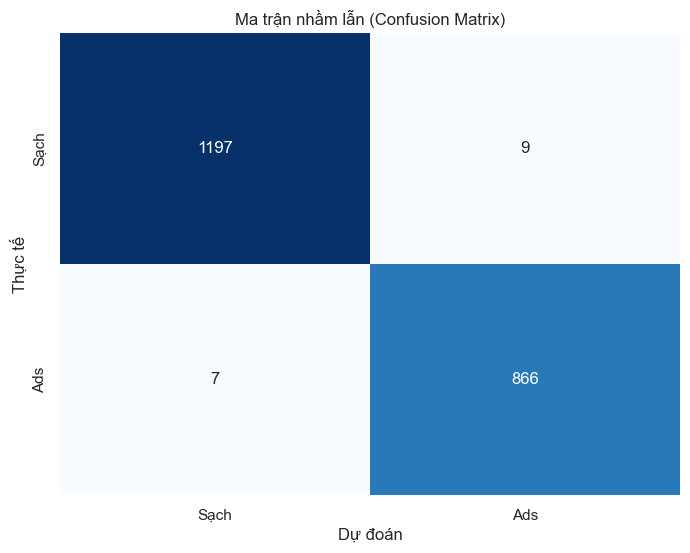

In [6]:
# Hình 1: Confusion Matrix
y_pred = rf.predict(X_test)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sạch', 'Ads'], yticklabels=['Sạch', 'Ads'], cbar=False)
plt.title("Ma trận nhầm lẫn (Confusion Matrix)")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.savefig('model3_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

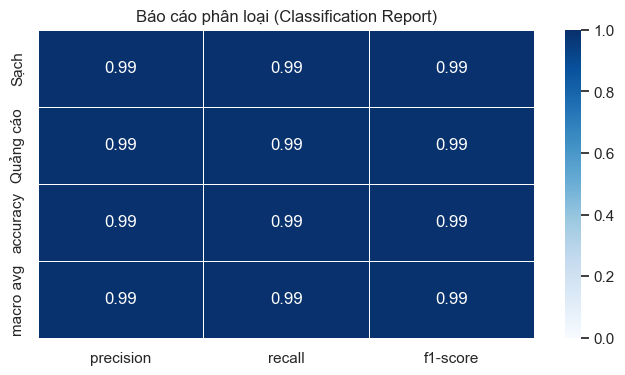

Độ chính xác tổng thể: 0.9923


In [7]:
# Hình 2: Classification Report
report = classification_report(y_test, y_pred,
                                target_names=['Sạch', 'Quảng cáo'],
                                output_dict=True)
report_df = pd.DataFrame(report).transpose().iloc[:-1, :3]

plt.figure(figsize=(8, 4))
sns.heatmap(report_df, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5)
plt.title("Báo cáo phân loại (Classification Report)")
plt.savefig('model3_classification_report.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Độ chính xác tổng thể: {accuracy_score(y_test, y_pred):.4f}")

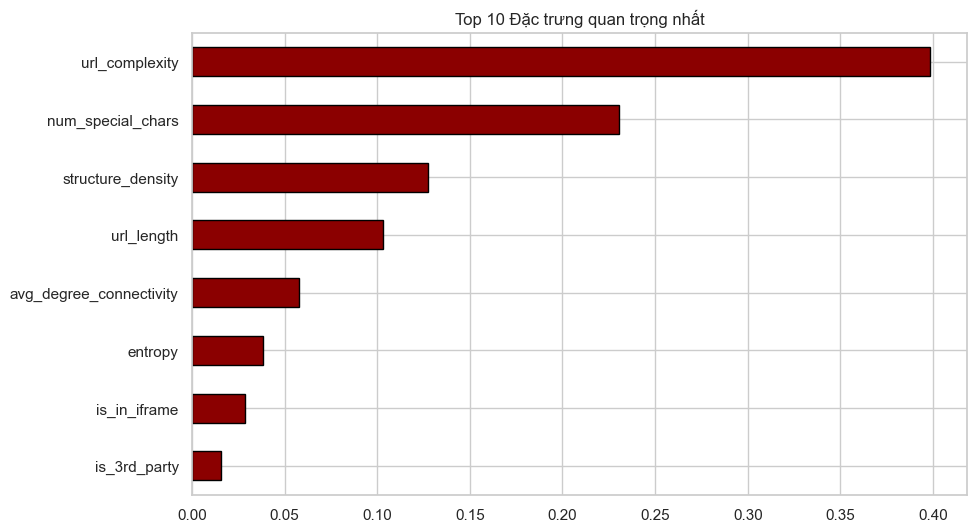

Đã lưu tệp mô hình: demo3_1.joblib


In [8]:
# Hình 3: Feature Importance & Lưu model
plt.figure(figsize=(10, 6))
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='darkred', edgecolor='black')
plt.title("Top 10 Đặc trưng quan trọng nhất")
plt.savefig('model3_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

joblib.dump({'model': rf, 'features': X.columns.tolist()}, 'demo3.joblib')
print("Đã lưu tệp mô hình: demo3_1.joblib")

In [9]:
# Kiểm tra với mẫu thực tế
test_ad = pd.DataFrame([{
    'is_3rd_party': 1,
    'url_length': 130,
    'entropy': 4.5,
    'num_special_chars': 14,
    'avg_degree_connectivity': 2,
    'is_in_iframe': 0,
    'structure_density': 0.125,
    'url_complexity': 0.155
}])

for col in X.columns:
    if col not in test_ad.columns:
        test_ad[col] = 0
test_ad = test_ad[X.columns]

prob = rf.predict_proba(test_ad)[0][1]
result = "QUẢNG CÁO" if prob > 0.6 else "SẠCH"

print(f"--- KẾT QUẢ KIỂM TRA ---")
print(f"Xác suất là quảng cáo: {prob*100:.2f}%")
print(f"Kết luận: {result}")

--- KẾT QUẢ KIỂM TRA ---
Xác suất là quảng cáo: 99.28%
Kết luận: QUẢNG CÁO
